# Análisis Explorativo de Datos (EDA)

**Propósito**: Hacer un pequeño análisis EDA con el cual poder hacer una pequeña introspeción en los datos.

In [2]:
import sys
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '/tfm/python_notebooks')
from tfm_lib import utils as tfm_utils

In [12]:
#Inicializar sesión de Spark
spark = tfm_utils.get_spark_session(app_name="ML_create_dataset")

#Cargamos los datos
df_data_spark=tfm_utils.read_from_delta(spark, "ml.idealista_crem.dataset_for_analysis")

df_data=df_data_spark.toPandas()

Antes de nada, es conveniente comprobar si el dataset presenta valores nulos o vacíos que deban ser eliminados o tratados. En este caso omitiremos esto ya sabemos que no hay registros con valores nulos.

Como podemos ver en la celda anterior toda la informacion está completa, por lo que no hay que hacer ningún tratamiendo a este respecto.

Visto esto haremos también un estudiamos los datos que disponemos, para ver como se distribuyen.

In [13]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
2015_renta_bruta_media_por_persona,10509.0,1.108633e-13,1.000000,-1.921859,-0.831372,-0.156767,1.215777,1.215777e+00
2016_distribucion_de_la_renta_p80_p20,10509.0,1.274366e-13,1.000000,-2.804895,-1.035674,0.025859,0.733547,1.795080e+00
2017_distribucion_de_la_renta_p80_p20,10509.0,1.857458e-13,1.000000,-2.624458,-1.121540,0.381379,0.757108,1.132838e+00
2017_transacciones_inmobiliarias,10509.0,-1.066659e-14,1.000000,-1.304822,-0.831007,-0.196411,0.878280,1.611152e+00
2018_transacciones_inmobiliarias,10509.0,-1.272202e-14,1.000000,-1.242997,-0.556324,0.035971,0.035971,2.194240e+00
2023_indice_de_gini,10509.0,5.015246e-14,1.000000,-3.498986,-0.565603,0.279608,0.975665,1.124820e+00
2023_tamano_poblacion,10509.0,-3.721408e-14,1.000000,-0.919800,-0.788263,-0.714602,1.570652,3.775229e+00
es_piso,10509.0,4.744505e-01,0.499371,0.000000,0.000000,0.000000,1.000000,1.000000e+00
estado_ocupacion_posible_ocupacion,10509.0,1.166619e-01,0.321032,0.000000,0.000000,0.000000,0.000000,1.000000e+00
estado_ocupacion_vacio,10509.0,8.506042e-01,0.356495,0.000000,1.000000,1.000000,1.000000,1.000000e+00


In [14]:
#Definimos las columnas que van a intervenir en nuestro modelo
columns_model=df_data.columns.tolist()

Antes de entrar con los modelo veamos graficamente la distribución de los datos. Usaremos graficos de tipo violín

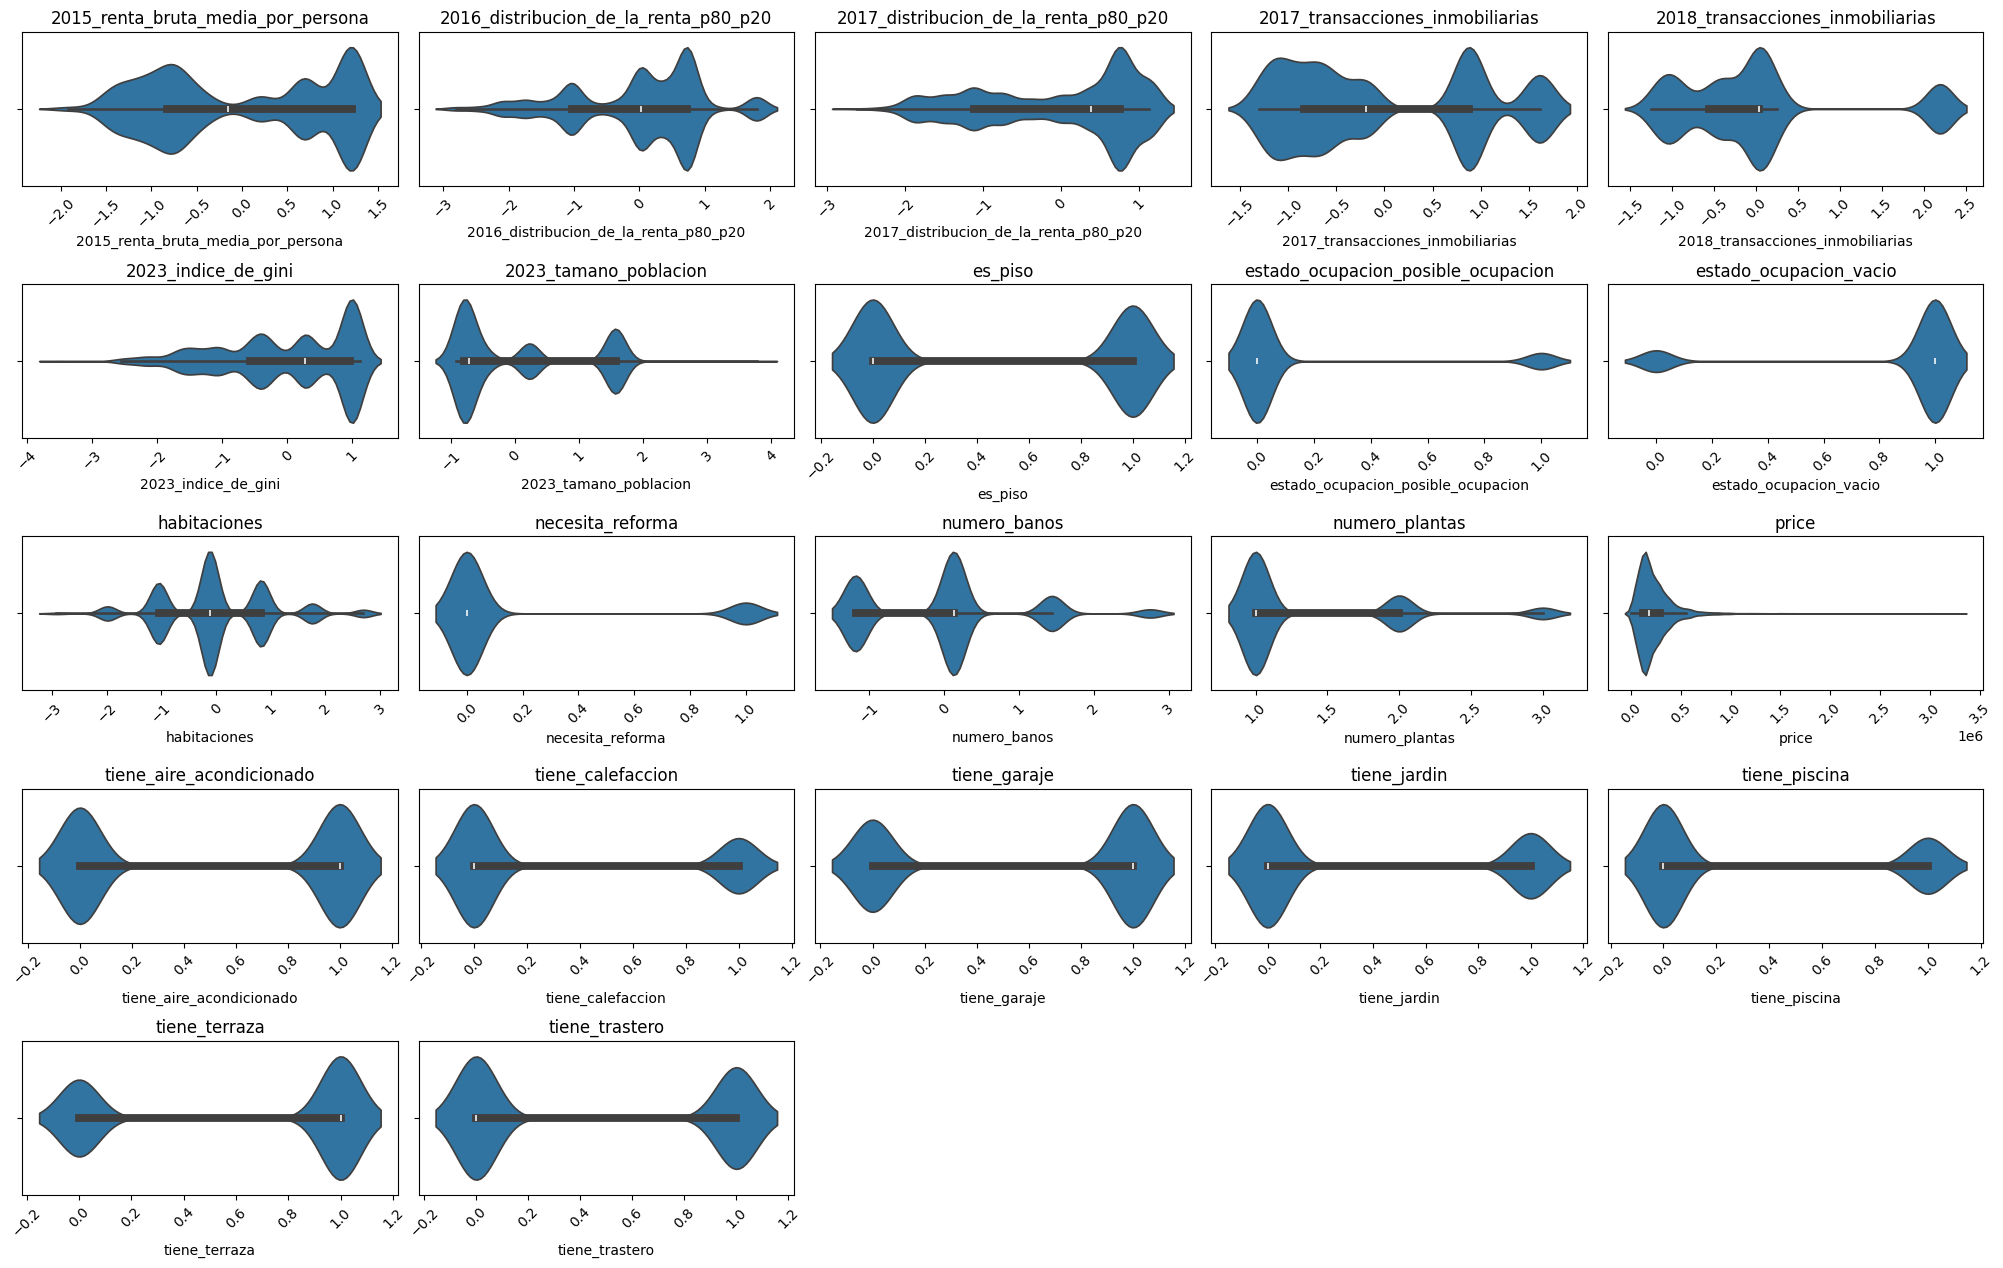

In [15]:
# Ajustar el tamaño total de la figura
plt.figure(figsize=(20, 50))

# Crear una matriz de subgráficos 5x20
for i, column in enumerate(columns_model):
    plt.subplot(20, 5, i + 1)
    sns.violinplot(x=df_data[column])
    plt.title(column)
    plt.xticks(rotation=45)  # Ajusta el ángulo de los nombres de las variables

# Ajustar el diseño para evitar superposiciones
plt.tight_layout()

# Mostrar el gráfico
plt.show()

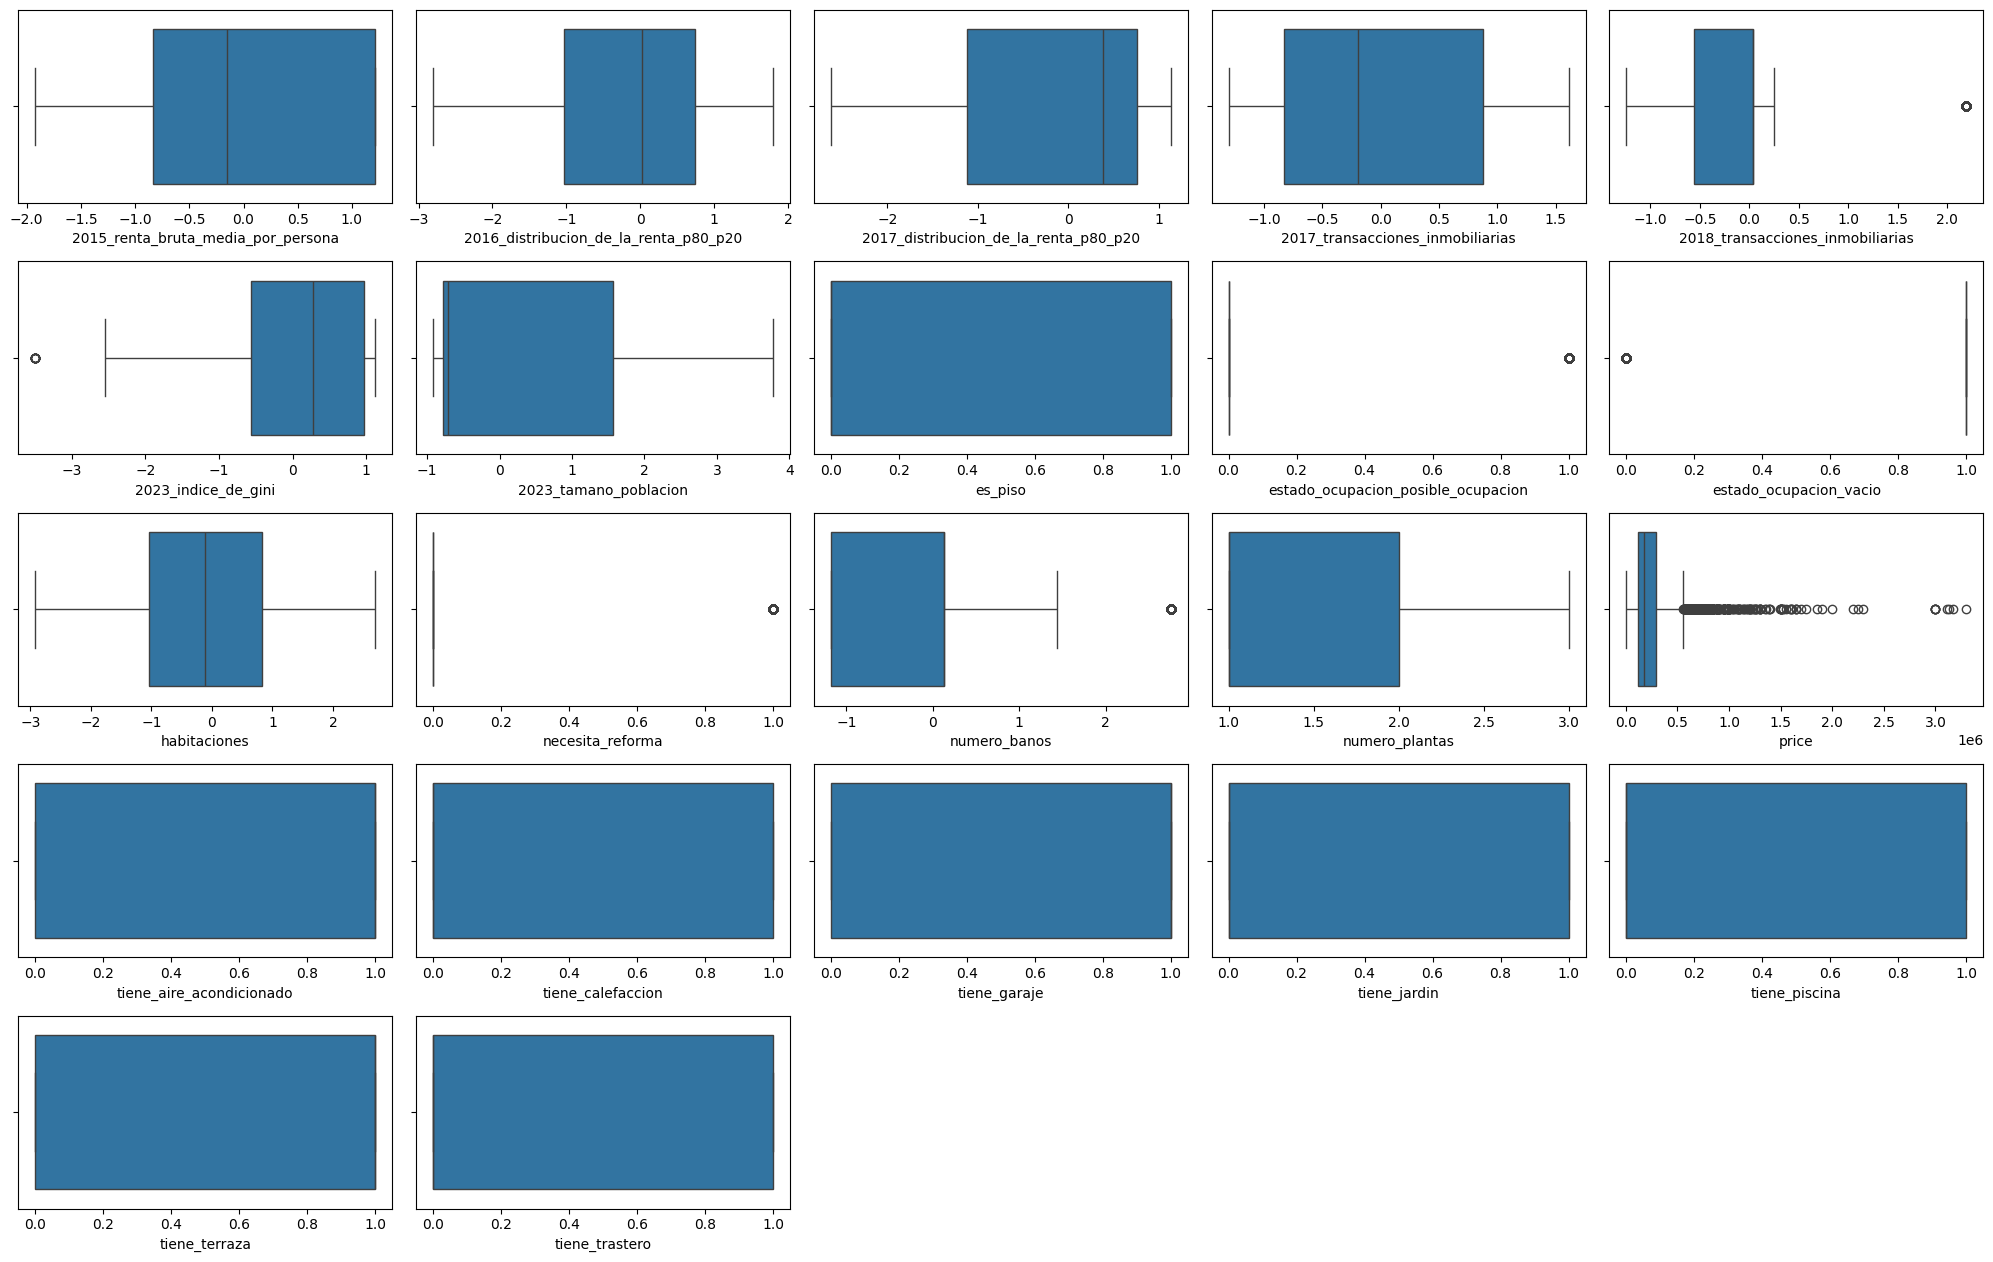

In [16]:
#Visualicemos ahora las cajas-bigote
#Lo hacemos solo sobre aquellas que no son sobre municipios
plt.figure(figsize=(20, 50))

# Crear una matriz de subgráficos 5x20
for i, column in enumerate(columns_model):
    plt.subplot(20, 5, i + 1)
    sns.boxplot(x=df_data[column])
    #plt.title(column)
    #plt.xticks(rotation=45)  # Ajusta el ángulo de los nombres de las variables

# Ajustar el diseño para evitar superposiciones
plt.tight_layout()

# Mostrar el gráfico
plt.show()

De aquí podemos sacar un poco de más de información de los datos:

- La distribución del precio se concentra la zona baja. En este caso en particular, los precios altos vienen a significar outliers.
- Hay una distribución parecida entre aquellas viviendas que tienen aire acondicionado, también podemos ver que, en el caso de la calefacción hay una concentración a no tener calefacción, esto es comprensible en un lugar como es Murcia donde los veranos son más duros que los invierno.
- La cantidad de viviendas que analizamos están casi simétricamente distribuidas respecto a la cantidad de habitaciones.
- Los anuncios están medianamente bien distribuidos para variables como la de tener terraza, tener trastero, ser piso o casa entre otras, como se puede ver en la imagen.
- La mayoría de viviendas publicadas tienen dos aseos, y la cantidad de viviendas con más de dos aseos es significativamente inferior a la que tienen 1 o dos.

Llegados a este punto, dada la existencia de datos *outliers* que podrían causar ruido a la hora de entrenar un modelo de predicción, un método aconsejable para solucionar esto sería aplicar algún método de detección de *outliers* como es el método del Rango intercuartílico.
Para utilizar este método, debemos calcular los percentiles 25 y 75, que se corresponden con los cuartiles 1 y 3 respectivamente. De aquí sacamos el rango intercuartílico, que es Q3 - Q1. A partir de este dato, calculamos el límite **superior** e **inferior** con la siguiente formula:

> **Límite superior** : cuartil 3 + 1.5 * rango intercuartílico.

> **Límite inferior** : cuartil 1 - 1.5 * rango intercuartílico.

Cualquier valor que se exceda de estos límites es considerado atípico y sustituido por la media.

In [7]:
def outliersIQR(s):
    Q1, Q3 = np.percentile(s, [25, 75])
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    replace = np.mean(s)
    s = s.where( (s >= lower) & (s <= upper) , replace)

    return s

Habría que aplicar esta función al dataframe construido hasta este punto. Ahora, esto estaría justificado cuando lo que queremos es usar este dataset para entrenar un modelo, sin embargo, en nuestro caso en particular, lo que haremos nosotros, antes de entrenar cualquier modelo de regresión, será aplicar un modelo de clústering, aplicar esta función lo que hace es *aplanar* los datos y forzar que se parezcan a las medias, concentrando ahí la probabilidad y los datos. La cosa es que los métodos de clústeriong crean grupos de elementos que se parecen entre sí, la existencia de outliers no tiene por que ser malo para estos modelos, todo lo contrario, puede ayudar a identificar mejor grupos en los que los elementos de cada uno de ellos se parezcan más entre sí. Cambiar esos outliers, y más cuando son tantos como vemos en las imagenes lo único que conseguiría es la creación de un sesgo muy grando, hasta el punto que, el resultado al aplicar un método como el anterior genere como un resultado un dataset que no sea representante de la población y la realidad, obteniendo resultados alejados de la misma.